In [1]:
import pandas as pd
import numpy as np

In [50]:
import sys
sys.path.append("../src")
%load_ext autoreload
%autoreload 2
from data_preprocess import select_columns, validate_dataframe, clean_data, encode_categoricals, norm_preprocessor, add_missing_indicator, map_to_nan

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
df_raw = pd.read_csv('../data/LC_loans_granting_model_dataset.csv')

/tmp/ipykernel_3771/1272200039.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../data/LC_loans_granting_model_dataset.csv')


Since there are 1.3 million lines, we make take some out used for testing

In [88]:
defaults = df_raw[df_raw['Default'] == 1].sample(n=2000, random_state=42)
non_defaults = df_raw[df_raw['Default'] == 0].sample(n=3000, random_state=42)
sample = pd.concat([defaults, non_defaults]).sample(frac=1, random_state=42)

sample.to_csv('../data/test/sample_loans.csv', index=False)

In [4]:
df_raw = df_raw.drop(columns=['id', 'title', 'desc', 'zip_code'])
print(df_raw.sample(10))
df_raw.info()

          issue_d   revenue  dti_n  loan_amnt  fico_n  experience_c  \
1313101  Nov-2016  110000.0  27.95      20000   707.0             1   
1222442  Aug-2016  103000.0  25.90      24000   677.0             1   
250708   May-2015   56000.0  14.45      18000   692.0             1   
256862   May-2015   52000.0  13.71      10000   697.0             1   
446205   Jun-2016   58000.0   5.96      12000   672.0             1   
155603   Aug-2015   61000.0  15.33      15000   747.0             1   
1288368  Oct-2017  135000.0  17.95      35000   702.0             1   
437786   Jul-2017   30000.0  28.24       6400   722.0             1   
373695   Jan-2015   62000.0  13.43       3600   672.0             1   
600833   Mar-2016   78000.0   8.06       5600   707.0             1   

        emp_length             purpose home_ownership_n addr_state  Default  
1313101  10+ years  debt_consolidation             RENT         NJ        0  
1222442     1 year    home_improvement         MORTGAGE       

In [5]:
df_raw.rename(columns={
    'loan_amnt': 'loan_amount', 'fico_n': 'fico_score', 'experience_c': 'has_experience', 'home_ownership_n': 'home_ownership', 'addr_state': 'state', 'Default': 'label', 'dti_n': 'indebtedness'
                      }, inplace=True)

In [6]:
print(df_raw.columns)

Index(['issue_d', 'revenue', 'indebtedness', 'loan_amount', 'fico_score',
       'has_experience', 'emp_length', 'purpose', 'home_ownership', 'state',
       'label'],
      dtype='object')


In [7]:
mandatory = ['revenue', 'loan_amount', 'fico_score', 'issue_year', 'issue_month' , 'issue_quarter' , 'post_crisis_recovery']
recommend = ['indebtedness', 'emp_length', 'purpose', 'home_ownership']
optional = ['state', 'has_experience']
label = 'label'

Add some extra features to make training better

In [8]:
df_raw['loan_to_income'] = df_raw['loan_amount'] / (df_raw['revenue'] + 1)
df_raw['monthly_payment_burden'] = (df_raw['loan_amount'] * 0.03) / (df_raw['revenue'] / 12 + 1)

In [10]:
for col in ['loan_to_income', 'monthly_payment_burden']:
    upper = df_raw[col].quantile(0.99)
    df_raw[col] = df_raw[col].clip(upper=upper)

In [11]:
top_states = df_raw['state'].value_counts().head(20).index.tolist()
df_raw['state'] = df_raw['state'].where(df_raw['state'].isin(top_states), 'Other')

In [12]:
df_raw['issue_d'] = pd.to_datetime(df_raw['issue_d'])
df_raw['issue_year'] = df_raw['issue_d'].dt.year
df_raw['issue_month'] = df_raw['issue_d'].dt.month
df_raw['issue_quarter'] = df_raw['issue_d'].dt.quarter
df_raw['post_crisis_recovery'] = ((df_raw['issue_year'] >= 2008) & (df_raw['issue_year'] <= 2010)).astype(int)
df_raw = df_raw.drop(columns=['issue_d'])

/tmp/ipykernel_3771/4135405611.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['issue_d'] = pd.to_datetime(df_raw['issue_d'])


Since there is only one missing zip_code and it is optional we can add a category as Unknown since we will be adding and training the model on missing data

We will only be adding missing data to the recommended and optional columns. Because of business logic there are some information that is mandatory. This can change depending on business logic

In [13]:
def add_missing(df, columns, frac = 0.1):
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            print(col + " column does not exist!")
            continue
        random_indices = df.sample(frac=frac).index
        df.loc[random_indices, col] = np.nan
    print("Done Adding Missing Data")
    return df
        

In [14]:
df_missing = add_missing(df_raw, recommend + optional)
print(df_missing.sample(10))
df_missing.info()

Done Adding Missing Data
          revenue  indebtedness  loan_amount  fico_score  has_experience  \
859416    55657.0         14.08        15000       712.0             1.0   
550499    75000.0         17.55        13000       742.0             1.0   
117461    51000.0           NaN         8000       722.0             NaN   
992070    60000.0         15.76        21000       677.0             1.0   
1141906   89846.0          4.74         3500       682.0             1.0   
399504    59000.0         18.45        17600       662.0             1.0   
1043691   86000.0         20.55        20000       697.0             1.0   
878979    57000.0         14.51         6600       667.0             1.0   
1215138   46500.0         18.40        17650       722.0             1.0   
1164485  112000.0          8.56        35000       807.0             1.0   

        emp_length             purpose home_ownership  state  label  \
859416     2 years  debt_consolidation       MORTGAGE  Other      0

In [15]:
print("Revenue Max: " + str(df_missing['revenue'].max()) + ", Min: " + str(df_missing['revenue'].min()))

Revenue Max: 10999200.0, Min: 1896.0


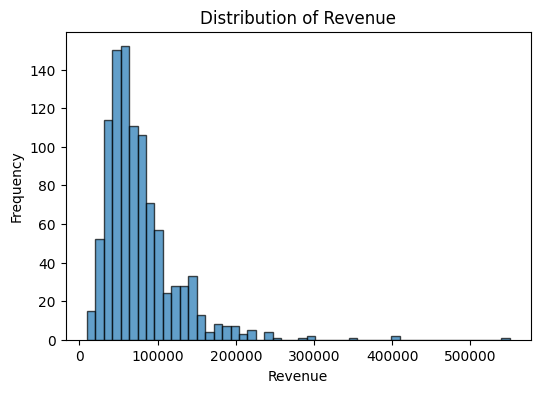

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(df_missing.sample(1000)['revenue'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

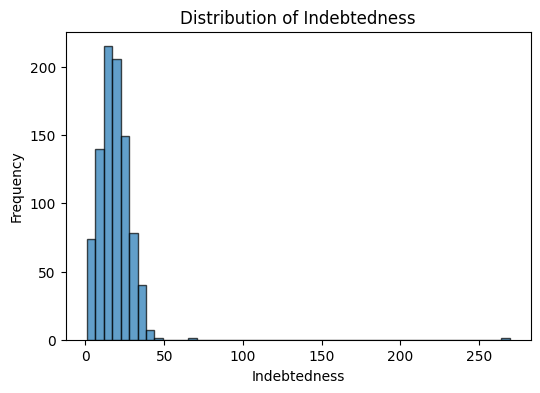

In [38]:
plt.figure(figsize=(6, 4))
plt.hist(df_missing.sample(1000)['indebtedness'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Indebtedness')
plt.xlabel('Indebtedness')
plt.ylabel('Frequency')
plt.show()

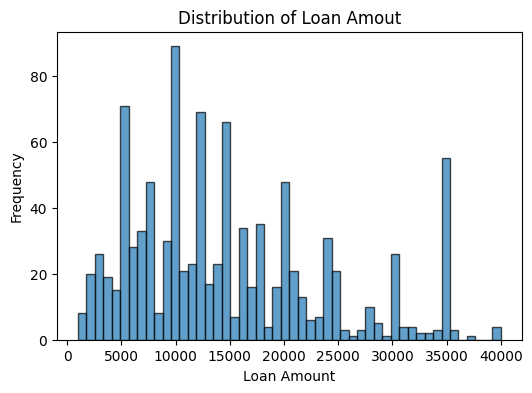

In [39]:
plt.figure(figsize=(6, 4))
plt.hist(df_missing.sample(1000)['loan_amount'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Loan Amout')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

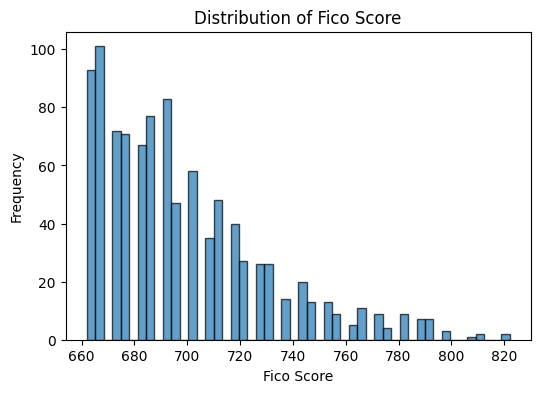

In [40]:
plt.figure(figsize=(6, 4))
plt.hist(df_missing.sample(1000)['fico_score'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Fico Score')
plt.xlabel('Fico Score') 
plt.ylabel('Frequency')
plt.show()

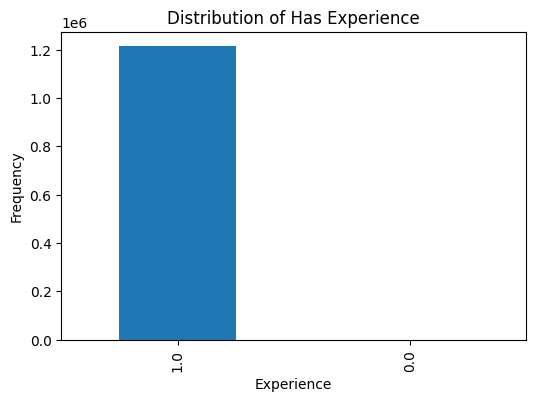

In [44]:
plt.figure(figsize=(6, 4))
df_missing['has_experience'].value_counts().plot(kind='bar')
plt.title('Distribution of Has Experience')
plt.xlabel('Experience')
plt.ylabel('Frequency')
plt.show()

In [43]:
print(df_missing['has_experience'].value_counts())

has_experience
1.0    1212890
0.0         23
Name: count, dtype: int64


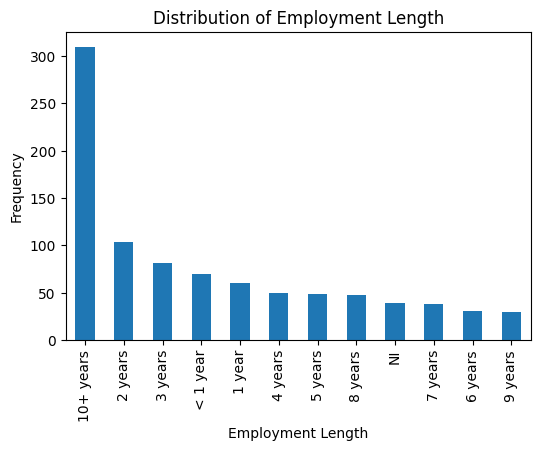

In [17]:
plt.figure(figsize=(6, 4))
df_missing.sample(1000)['emp_length'].value_counts().plot(kind='bar')
plt.title('Distribution of Employment Length')
plt.xlabel('Employment Length')
plt.ylabel('Frequency')
plt.show()

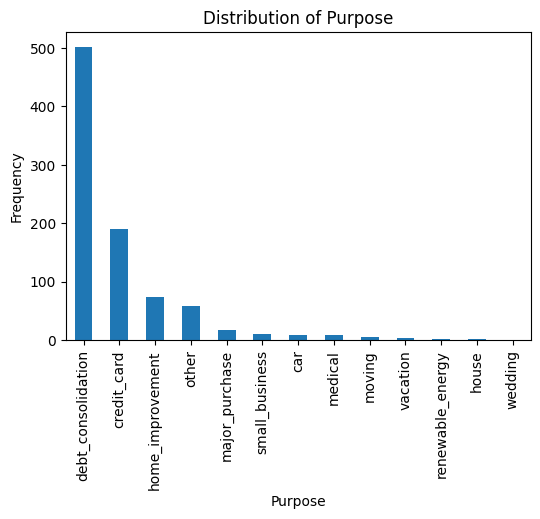

In [46]:
plt.figure(figsize=(6, 4))
df_missing.sample(1000)['purpose'].value_counts().plot(kind='bar')
plt.title('Distribution of Purpose')
plt.xlabel('Purpose')
plt.ylabel('Frequency')
plt.show()

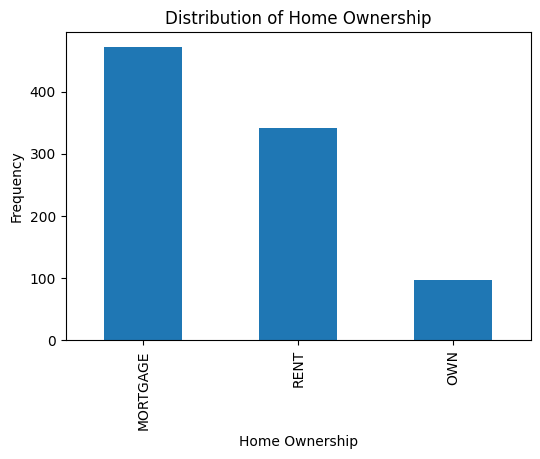

In [47]:
plt.figure(figsize=(6, 4))
df_missing.sample(1000)['home_ownership'].value_counts().plot(kind='bar')
plt.title('Distribution of Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Frequency')
plt.show()

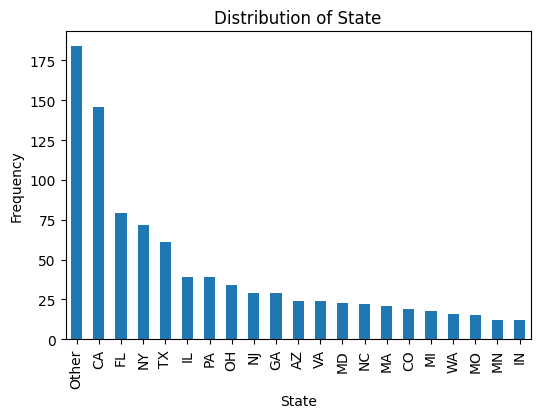

In [29]:
plt.figure(figsize=(6, 4))
df_missing.sample(1000)['state'].value_counts().plot(kind='bar')
plt.title('Distribution of State')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.show()

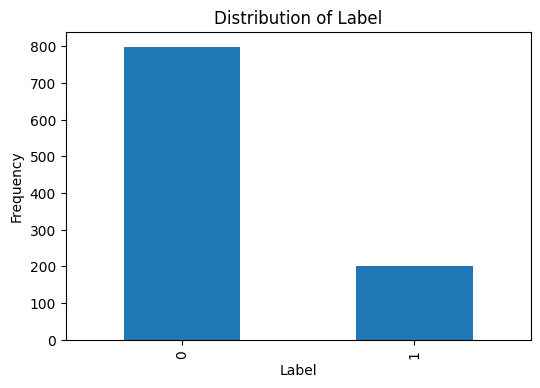

In [51]:
plt.figure(figsize=(6, 4))
df_missing.sample(1000)['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Label')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

Handle Missing Values: For categorical columns we will use a unknown category and for numerical we will use the median but also use a indicator that it was missing.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [16]:
mandatory_num = ['revenue', 'loan_amount', 'fico_score', 'loan_to_income', 'monthly_payment_burden', 'issue_year', 'issue_month' , 'issue_quarter' , 'post_crisis_recovery']
missing_num = ['indebtedness', 'emp_length']
missing_cat = ['purpose', 'home_ownership', 'state', 'has_experience']

In [17]:
df_missing_map = map_to_nan(df_missing, 'emp_length', 'NI')

In [83]:
print(df_missing['emp_length'].isna().sum())

134768


In [18]:
df_missing_ind = add_missing_indicator(df_missing, missing_num)
print(df_missing_ind.sample())

         revenue  indebtedness  loan_amount  fico_score  has_experience  \
1026798  40500.0         21.93         4800       687.0             1.0   

        emp_length             purpose home_ownership state  label  \
1026798    5 years  debt_consolidation           RENT    WA      0   

         loan_to_income  monthly_payment_burden  issue_year  issue_month  \
1026798        0.118516                0.042654        2013           11   

         issue_quarter  post_crisis_recovery  indebtedness_missing  \
1026798              4                     0                     0   

         emp_length_missing  
1026798                   0  


In [19]:
emp_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}
df_missing_ind['emp_length'] = df_missing_ind['emp_length'].map(emp_map)

In [82]:
print(df_missing_ind['emp_length'].value_counts())
print(df_missing_ind['emp_length'].isna().sum())

emp_length
10.0    398408
2.0     109875
0.0      97665
3.0      97114
1.0      80135
5.0      75817
4.0      72668
6.0      56473
8.0      54734
7.0      53715
9.0      45987
Name: count, dtype: int64
205090


In [21]:
df_clean = clean_data(df_missing_ind, missing_num, missing_cat)
print(df_clean.sample())

        revenue  indebtedness  loan_amount  fico_score has_experience  \
656676  67000.0         29.05        15000       677.0            1.0   

        emp_length             purpose home_ownership state  label  \
656676        10.0  debt_consolidation       MORTGAGE    NY      0   

        loan_to_income  monthly_payment_burden  issue_year  issue_month  \
656676        0.223877                0.080583        2016            1   

        issue_quarter  post_crisis_recovery  indebtedness_missing  \
656676              1                     0                     0   

        emp_length_missing  
656676                   0  


In [22]:
df_encode = encode_categoricals(df_clean, missing_cat)
print(df_encode.sample())

         revenue  indebtedness  loan_amount  fico_score  emp_length  label  \
862882  120000.0         27.64        21000       672.0         4.0      0   

        loan_to_income  monthly_payment_burden  issue_year  issue_month  ...  \
862882        0.174999                0.062994        2014            3  ...   

        state_OH  state_Other  state_PA  state_TX  state_UnKnown  state_VA  \
862882     False        False     False     False          False     False   

        state_WA  has_experience_0.0  has_experience_1.0  \
862882     False               False                True   

        has_experience_UnKnown  
862882                   False  

[1 rows x 59 columns]


In [23]:
df_encode['emp_length'] = df_encode['emp_length'].astype(int)

In [51]:
standard_norm = ['indebtedness', 'revenue', 'loan_amount', 'loan_to_income', 'monthly_payment_burden', 'issue_year']
minmax_norm = [ 'emp_length', 'fico_score', 'issue_month' , 'issue_quarter']

In [52]:
preprocessor = norm_preprocessor(standard_norm, minmax_norm)

Split the data into training and testing and validation

In [53]:
x = df_encode.drop(columns=[label])
y = df_encode[label]

In [54]:
x.info()
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 58 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   revenue                     1347681 non-null  float64
 1   indebtedness                1347681 non-null  float64
 2   loan_amount                 1347681 non-null  int64  
 3   fico_score                  1347681 non-null  float64
 4   emp_length                  1347681 non-null  int64  
 5   loan_to_income              1347681 non-null  float64
 6   monthly_payment_burden      1347681 non-null  float64
 7   issue_year                  1347681 non-null  int32  
 8   issue_month                 1347681 non-null  int32  
 9   issue_quarter               1347681 non-null  int32  
 10  post_crisis_recovery        1347681 non-null  int64  
 11  indebtedness_missing        1347681 non-null  int64  
 12  emp_length_missing          1347681 non-null  int64  
 1

In [55]:
features_train, features_test, target_train, target_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [56]:
features_train_scaled = preprocessor.fit_transform(features_train)
features_test_scaled = preprocessor.transform(features_test)

In [57]:
import yaml
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve

In [75]:
with open("../configs/logistic_regression_v2.yaml") as f:
    config = yaml.safe_load(f)
# with open("../configs/random_forest_v1.yaml") as f:
#     config = yaml.safe_load(f)
# with open("../configs/gradient_boosting_v3.yaml") as f:
#     config = yaml.safe_load(f)
# with open("../configs/xgboost_v1.yaml") as f:
#     config = yaml.safe_load(f)

In [69]:
def get_model(config):
    if config is None:
        print("No Config File!!")
        return None
    model = None
    if config["model"] == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=config["params"]["n_estimators"], 
            max_depth=config["params"]["max_depth"],
            random_state=config["params"]["random_state"],
            # min_samples_leaf=config["params"]["min_samples_leaf"],
            class_weight='balanced'
        )
    elif config["model"] == "Logistic Regression":
        model = LogisticRegression(
            C=config["params"]["C"],
            max_iter=config["params"]["max_iter"],
            random_state=config["params"]["random_state"],
            class_weight='balanced'
        )
    elif config["model"] == "Gradient Boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=config["params"]["learning_rate"],
            max_depth=config["params"]["max_depth"],
            random_state=config["params"]["random_state"],
            max_iter=config["params"]["max_iter"],
            class_weight='balanced',
            min_samples_leaf=config["params"]["min_samples_leaf"],
            early_stopping=config["params"]["early_stopping"],
            l2_regularization=config["params"]["l2_regularization"]
        )
    elif config["model"] == "XGBoost":
        return XGBClassifier(
            n_estimators=config["params"]["n_estimators"],
            learning_rate=config["params"]["learning_rate"],
            max_depth=config["params"]["max_depth"],
            min_child_weight=config["params"]["min_child_weight"],
            subsample=config["params"]["subsample"],
            colsample_bytree=config["params"]["colsample_bytree"],
            gamma=config["params"]["gamma"],
            reg_lambda=config["params"]["reg_lambda"],
            scale_pos_weight=config["params"]["scale_pos_weight"],
            random_state=config["params"]["random_state"],
            n_jobs=-1,
            eval_metric='auc',
            tree_method='hist',  # fast histogram-based, equivalent to LightGBM's approach
        )
    return model

In [60]:
import mlflow
import mlflow.sklearn
import json
import os
from pathlib import Path
mlflow.set_tracking_uri(f"file://{Path.cwd().parent / 'mlruns'}")

In [66]:
def run_experiment(config):
    model = get_model(config)
    if model is None:
        return

    print(model)

    mlflow.set_experiment("loan-prediction")
    

    with mlflow.start_run():
        mlflow.log_param("model", config["model"])
        mlflow.log_param("random_state", config["params"]["random_state"])

        if config["model"] == "Logistic Regression":
            mlflow.log_param("C", config["params"]["C"])
            mlflow.log_param("max_iter", str(config["params"]["max_iter"]))
        elif config["model"] == "Random Forest":
            mlflow.log_param("n_estimators", str(config["params"]["n_estimators"]))
            mlflow.log_param("max_depth", str(config["params"]["max_depth"]))
            # mlflow.log_param("min_samples_leaf", str(config["params"]["min_samples_leaf"]))
        elif config["model"] == "Gradient Boosting":
            mlflow.log_param("learning_rate", str(config["params"]["learning_rate"]))
            mlflow.log_param("max_depth", str(config["params"]["max_depth"]))
            mlflow.log_param("max_iter", str(config["params"]["max_iter"]))
            mlflow.log_param("min_samples_leaf", str(config["params"]["min_samples_leaf"]))
        elif config["model"] == "XGBoost":
            mlflow.log_param("n_estimators", str(config["params"]["n_estimators"]))
            mlflow.log_param("max_depth", str(config["params"]["max_depth"]))
            mlflow.log_param("learning_rate", str(config["params"]["learning_rate"]))
            

        #Train--
        model.fit(features_train_scaled, target_train)

        #Eval--
        y_pred = model.predict(features_test_scaled)
        y_prob = model.predict_proba(features_test_scaled)[:, 1]

        print("Predictions:", np.unique(y_pred, return_counts=True))
        print("Probabilities — min:", y_prob.min(), "max:", y_prob.max())

        accuracy = accuracy_score(target_test, y_pred)
        precision = precision_score(target_test, y_pred)
        recall = recall_score(target_test, y_pred)
        f1 = f1_score(target_test, y_pred)
        auc = roc_auc_score(target_test, y_prob)

        # ── Log metrics ──
        mlflow.log_metric("accuracy", round(accuracy, 4))
        mlflow.log_metric("precision", round(precision, 4))
        mlflow.log_metric("recall", round(recall, 4))
        mlflow.log_metric("f1_score", round(f1, 4))
        mlflow.log_metric("auc_roc", round(auc, 4))

        # ── Log the trained model as an artifact ──
        mlflow.sklearn.log_model(model, "model")

        # ── Log the config file as an artifact for reference ──
        config_path = "config_snapshot.json"
        with open(config_path, "w") as f:
            json.dump(config, f, indent=2, default=str)
        mlflow.log_artifact(config_path)
        os.remove(config_path)  # clean up temp file

        # ── Print results ──
        print(f"\n{'='*50}")
        print(f"Model:     {config['model']}")
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1 Score:  {f1:.4f}")
        print(f"AUC-ROC:   {auc:.4f}")
        print(f"{'='*50}")

        run_id = mlflow.active_run().info.run_id
        print(f"\nMLflow Run ID: {run_id}")
        print("View this run in the UI: mlflow ui")

    return run_id

In [76]:
run_experiment(config=config)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)


2026/05/07 20:55:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Predictions: (array([0, 1]), array([149977, 119560]))
Probabilities — min: 0.037673116698308126 max: 0.9999999978234906


2026/05/07 20:55:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Model:     Logistic Regression
Accuracy:  0.6086
Precision: 0.2832
Recall:    0.6311
F1 Score:  0.3910
AUC-ROC:   0.6632

MLflow Run ID: dd19b7a749fe4ff7a22cf3b82bb23296
View this run in the UI: mlflow ui


'dd19b7a749fe4ff7a22cf3b82bb23296'

In [79]:
print("Train target distribution:", target_train.value_counts())
print("Test target distribution:", target_test.value_counts())

Train target distribution: label
0    862554
1    215590
Name: count, dtype: int64
Test target distribution: label
0    215878
1     53659
Name: count, dtype: int64


In [70]:
import pandas as pd



NameError: name 'model' is not defined